In [2]:
from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB
from database.db_manager import DatabaseManager
import random
import time
import matplotlib.pyplot as plt

## Introduction

Efficient data storage and retrieval are fundamental challenges in database systems, especially as the volume of data continues to grow. 
Naive approaches that rely on linear scanning or unstructured storage become increasingly inefficient for large datasets, particularly when handling search and range-based queries.

In this project, a lightweight database system is developed using a B+ Tree as the core indexing structure. 
The B+ Tree is a self-balancing, multi-level tree that maintains sorted data and ensures logarithmic time complexity for insertion, search, and deletion operations. 
Its design, which separates internal routing nodes from data-storing leaf nodes, makes it especially well-suited for database indexing.

The implemented system supports:
- Insertion, deletion, and update of records
- Exact key-based search
- Efficient range queries using linked leaf nodes
- A table abstraction with schema validation for structured data management

To evaluate the effectiveness of the B+ Tree, a comparative performance analysis is conducted against a brute-force implementation based on a Python dictionary. 
While the brute-force approach provides constant-time performance for individual operations, it lacks efficiency for ordered and range-based queries.

This project highlights the trade-offs between simple data structures and structured indexing, demonstrating why B+ Trees are widely used in real-world database systems.

Implementation

### B+ Tree Design

The B+ Tree was implemented from scratch using a node-based structure. Each node maintains:
- A list of keys for indexing
- A list of children (for internal nodes)
- A list of values (for leaf nodes)
- A pointer to the next leaf node

Leaf nodes store actual data records, while internal nodes only guide traversal.



In [3]:
from database.bplustree import BPlusTree

tree = BPlusTree(order=3)

print("B+ Tree initialized")

B+ Tree initialized


### Insertion Mechanism

Insertion follows a recursive approach:
- The algorithm traverses down to the correct leaf node
- Keys are inserted in sorted order
- If a node becomes full, it is split into two nodes

For leaf nodes:
- The split divides keys evenly
- The first key of the new node is promoted to the parent
- Leaf nodes are linked using a `next` pointer to support efficient range queries

For internal nodes:
- A middle key is promoted upward
- Children are redistributed accordingly

This ensures that the tree remains balanced at all times.



In [4]:
# Insert keys in random order

tree.insert(50, "A")
tree.insert(10, "B")
tree.insert(30, "C")
tree.insert(70, "D")
tree.insert(20, "E")
tree.insert(60, "F")

print("Insertion complete")

Insertion complete


## Get All Records

Retrieves all records in sorted order.

- Starts from the leftmost leaf node  
- Traverses using linked leaf nodes (`next`)  

**Time Complexity:** O(n)

In [5]:
tree.get_all() #shows sorted data even though randomly inserted


[(10, 'B'), (20, 'E'), (30, 'C'), (50, 'A'), (60, 'F'), (70, 'D')]

### Search Operation

Search begins at the root and traverses down:
- Internal nodes are used to decide the correct child path
- The search eventually reaches a leaf node
- A linear scan within the leaf retrieves the value

This structure ensures logarithmic search complexity.



In [6]:
tree.search(30)

'C'

### Deletion Mechanism

Deletion removes a key from the leaf node and then ensures tree balance:
- If a node has fewer keys than required, rebalancing is triggered
- Rebalancing is handled using:
  - Borrowing from sibling nodes
  - Merging with sibling nodes

Additionally, internal node keys are updated dynamically to maintain correct routing.


In [7]:
tree.delete(30)

tree.get_all()

[(10, 'B'), (20, 'E'), (50, 'A'), (60, 'F'), (70, 'D')]


### Range Query Optimization

Range queries are efficiently handled using:
- Traversal to the starting leaf node
- Sequential traversal using linked leaf nodes (`next` pointers)

This avoids repeated tree traversal and makes range queries significantly faster.


In [8]:
tree.range_query(20, 60)

[(20, 'E'), (50, 'A'), (60, 'F')]

## Update Operation

Updates an existing record using its primary key.

- Validates the new record  
- Finds the key using B+ Tree  
- Updates the value in the leaf node  

**Time Complexity:** O(log n)

In [9]:
# Update value for an existing key

print("Before update:")
print(tree.search(20))

# Update operation
tree.update(20, "Z")

print("After update:")
print(tree.search(20))

Before update:
E
After update:
Z



---

### Brute Force Approach

The brute-force implementation uses a Python dictionary:
- Insertions are done via direct key assignment
- Search operations use built-in dictionary lookup
- Range queries iterate through all key-value pairs

While dictionary lookup is efficient for exact search, range queries require scanning the entire dataset, making it less efficient for large data.

In [10]:
db = DatabaseManager()

# Create database
db.create_database("college")

# Create table
db.create_table(
    db_name="college",
    table_name="students",
    schema=["id", "name"],
    search_key="id"
)

# Get table
students = db.get_table("college", "students")

# Insert
students.insert({"id": 1, "name": "Alice"})
students.insert({"id": 2, "name": "Bob"})
students.insert({"id": 3, "name": "Charlie"})

# Search 
print("Search:", students.get(1))

# Range Query
print("Range:", students.range_query(1, 3))

# Update
students.update(2, {"id": 2, "name": "Bob Updated"})
print("Updated:", students.get(2))

# Delete
students.delete(1)
print("After delete:", students.get(1))

# Get all
print("All records:", students.get_all())

Search: {'id': 1, 'name': 'Alice'}
Range: [{'id': 1, 'name': 'Alice'}, {'id': 2, 'name': 'Bob'}, {'id': 3, 'name': 'Charlie'}]
Updated: {'id': 2, 'name': 'Bob Updated'}
After delete: None
All records: [{'id': 2, 'name': 'Bob Updated'}, {'id': 3, 'name': 'Charlie'}]


### Explanation

- A database named "college" is created.
- A table "students" is initialized with schema validation.
- Records are inserted as dictionaries.
- The B+ Tree indexes records using the primary key (`id`).
- Operations such as search, update, delete, and range query are demonstrated.

# Performance Analysis

### Insertion Analysis

In [11]:
sizes = [1000, 3000, 5000, 8000]

bpt_insert = []
bf_insert = []

for size in sizes:
    keys = random.sample(range(1, 100000), size)

    bpt = BPlusTree(order=8)
    bf = BruteForceDB()

    # B+ Tree insert
    start = time.time()
    for k in keys:
        bpt.insert(k, k)
    bpt_insert.append(time.time() - start)

    # Brute force insert
    start = time.time()
    for k in keys:
        bf.insert(k, k)
    bf_insert.append(time.time() - start)

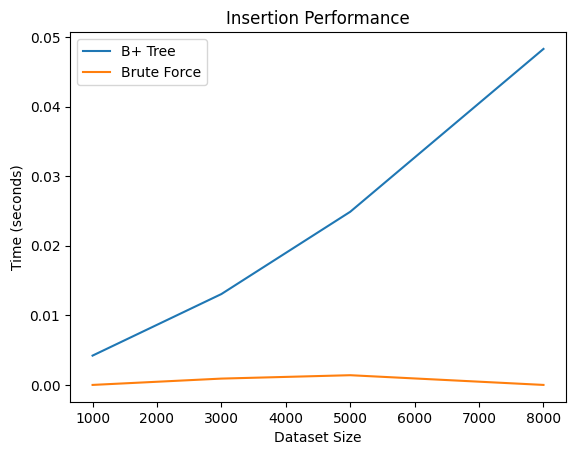

In [12]:
plt.figure()
plt.plot(sizes, bpt_insert, label="B+ Tree")
plt.plot(sizes, bf_insert, label="Brute Force")
plt.xlabel("Dataset Size")
plt.ylabel("Time (seconds)")
plt.title("Insertion Performance")
plt.legend()
plt.show()

Insertion performance differs significantly between the B+ Tree and the brute-force approach due to their underlying data structures.

In the brute-force implementation, insertion is performed using a Python dictionary:

- A new key-value pair is directly added using hash-based indexing
- This results in a constant-time complexity of \(O(1)\)

This makes brute-force insertion extremely fast for individual operations.

In contrast, insertion in the B+ Tree involves multiple steps:

- Traversing the tree from the root to the appropriate leaf node \(O(log n)\)
- Inserting the key in sorted order within the leaf node
- Checking for node overflow
- Splitting nodes when they exceed capacity and propagating changes upward

Due to these steps, the overall insertion time complexity is \(O(\log n)\).

However, this additional overhead ensures that the tree remains balanced and sorted at all times. This structure enables efficient searching and range queries, which are critical for database systems.

#####  Observation

Although brute-force insertion is faster in isolation, the B+ Tree provides better long-term performance by maintaining an organized structure, which improves the efficiency of other operations.

### Search Analysis

In [13]:
bpt_search = []
bf_search = []

for size in sizes:
    keys = random.sample(range(1, 100000), size)

    bpt = BPlusTree(order=8)
    bf = BruteForceDB()

    # Insert first
    for k in keys:
        bpt.insert(k, k)
        bf.insert(k, k)

    search_keys = random.sample(keys, min(500, size))

    # B+ Tree search
    start = time.time()
    for k in search_keys:
        bpt.search(k)
    bpt_search.append(time.time() - start)

    # Brute force search
    start = time.time()
    for k in search_keys:
        bf.search(k)
    bf_search.append(time.time() - start)

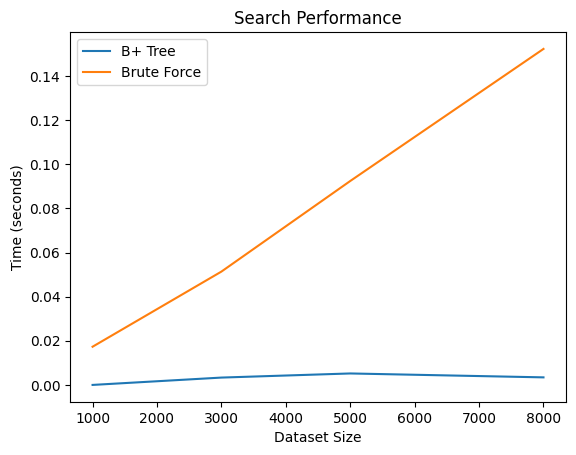

In [14]:
plt.figure()
plt.plot(sizes, bpt_search, label="B+ Tree")
plt.plot(sizes, bf_search, label="Brute Force")
plt.xlabel("Dataset Size")
plt.ylabel("Time (seconds)")
plt.title("Search Performance")
plt.legend()
plt.show()

Search performance highlights the fundamental difference between structured indexing and direct lookup.

In the brute-force implementation, search is performed using a Python dictionary:

- The key is accessed directly using hash-based lookup
- This results in a constant-time complexity of \(O(1)\)

This makes brute-force search extremely fast for exact key lookups.

In contrast, search in the B+ Tree involves:

- Traversing the tree from the root node
- At each internal node, selecting the appropriate child based on key comparisons
- Reaching the correct leaf node and performing a local scan

Since the height of the tree is logarithmic, the overall time complexity is:

\[
O(log n)
\]

##### Observation

Although brute-force search is faster for individual lookups, the B+ Tree provides structured access to data. This becomes especially beneficial when combined with other operations such as range queries and ordered traversal.

Thus, while dictionary-based search is optimal for isolated queries, the B+ Tree offers a more balanced and scalable solution for database systems.

### Range Query Analysis

In [15]:
bpt_range = []
bf_range = []

for size in sizes:
    keys = random.sample(range(1, 100000), size)

    bpt = BPlusTree(order=8)
    bf = BruteForceDB()

    # Insert first
    for k in keys:
        bpt.insert(k, k)
        bf.insert(k, k)

    start_key = size // 10
    end_key = size // 2

    # B+ Tree range query
    start = time.time()
    bpt.range_query(start_key, end_key)
    bpt_range.append(time.time() - start)

    # Brute force range query
    start = time.time()
    bf.range_query(start_key, end_key)
    bf_range.append(time.time() - start)

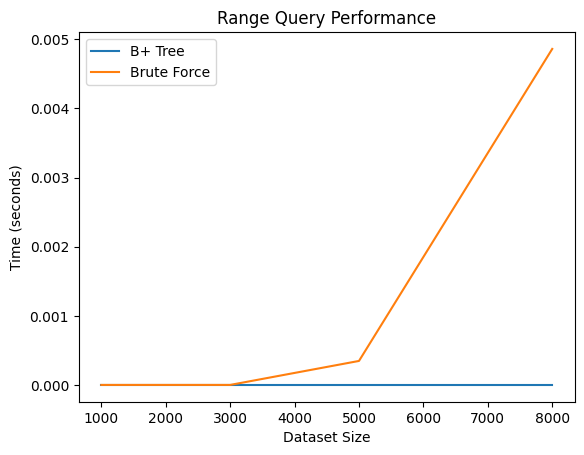

In [16]:
plt.figure()
plt.plot(sizes, bpt_range, label="B+ Tree")
plt.plot(sizes, bf_range, label="Brute Force")
plt.xlabel("Dataset Size")
plt.ylabel("Time (seconds)")
plt.title("Range Query Performance")
plt.legend()
plt.show()

Range queries demonstrate the most significant performance advantage of the B+ Tree over the brute-force approach.

In the brute-force implementation:

- The entire dataset is scanned using iteration over all key-value pairs
- Each key is checked to determine whether it lies within the specified range

This results in a linear time complexity:

\[
O(n)
\]

In contrast, the B+ Tree is specifically optimized for range queries:

- The tree is first traversed to locate the starting key \(O(\log n)\)
- From there, leaf nodes are sequentially accessed using the `next` pointer
- Only relevant keys within the range are processed

This results in an efficient time complexity:

\[
O(log n + k)
\]

where \(k\) is the number of elements in the result.

##### Observation

The use of linked leaf nodes allows the B+ Tree to avoid scanning the entire dataset. Instead, it directly accesses only the required portion of data.

As the dataset size increases, this advantage becomes more significant, making the B+ Tree far more efficient than the brute-force approach for range-based operations.

This clearly demonstrates why B+ Trees are widely used in real-world database indexing systems.

### Deletion Analysis

In [17]:
bpt_delete = []
bf_delete = []

for size in sizes:
    keys = random.sample(range(1, 100000), size)

    bpt = BPlusTree(order=8)
    bf = BruteForceDB()

    # Insert first
    for k in keys:
        bpt.insert(k, k)
        bf.insert(k, k)

    delete_keys = random.sample(keys, min(500, size))

    # B+ Tree delete
    start = time.time()
    for k in delete_keys:
        bpt.delete(k)
    bpt_delete.append(time.time() - start)

    # Brute force delete
    start = time.time()
    for k in delete_keys:
        bf.delete(k)
    bf_delete.append(time.time() - start)

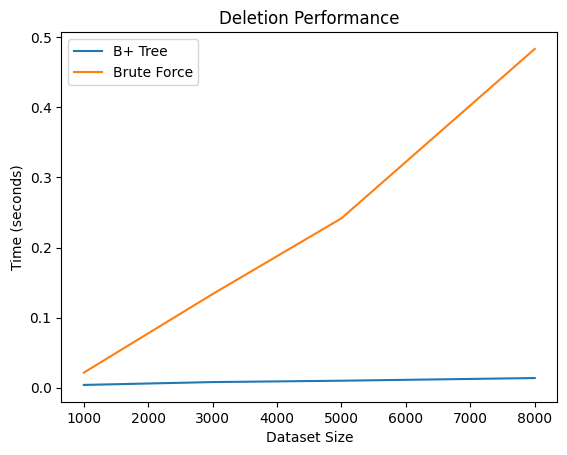

In [18]:
plt.figure()
plt.plot(sizes, bpt_delete, label="B+ Tree")
plt.plot(sizes, bf_delete, label="Brute Force")
plt.xlabel("Dataset Size")
plt.ylabel("Time (seconds)")
plt.title("Deletion Performance")
plt.legend()
plt.show()

Deletion in the brute-force approach is performed using direct removal from a Python dictionary:

- The key is removed using a constant-time operation \(O(1)\)
- No structural adjustments are required after deletion

This makes brute-force deletion very efficient for individual operations.

In contrast, deletion in the B+ Tree is more complex and involves several steps:

- Traversing the tree from root to leaf to locate the key \(O(\log n)\)
- Removing the key from the leaf node
- Ensuring the node satisfies minimum key constraints
- Performing rebalancing operations such as:
  - Borrowing keys from sibling nodes
  - Merging nodes when redistribution is not possible
- Updating parent separator keys to maintain correct structure

These operations result in an overall time complexity of \(O(log n)\).

##### Observation

Although brute-force deletion is theoretically faster, the B+ Tree maintains a balanced and sorted structure after every deletion. This ensures consistent performance across all operations and avoids degradation in efficiency for search and range queries.

In practice, the B+ Tree deletion performance was observed to be competitive due to localized updates along a single traversal path.

### Random Performance Test

In [19]:
bpt_random = []
bf_random = []

for size in sizes:
    print(f"Random operations for size: {size}")

    keys = random.sample(range(1, 100000), size)

    bpt = BPlusTree(order=8)
    bf = BruteForceDB()

    operations = []

    # Prepare random operations
    for k in keys:
        operations.append(("insert", k))

    for k in random.sample(keys, min(500, size)):
        operations.append(("search", k))

    for k in random.sample(keys, min(500, size)):
        operations.append(("delete", k))

    random.shuffle(operations)

    # B+ Tree
    start = time.time()
    for op, k in operations:
        if op == "insert":
            bpt.insert(k, k)
        elif op == "search":
            bpt.search(k)
        elif op == "delete":
            bpt.delete(k)
    bpt_random.append(time.time() - start)

    # BruteForce
    start = time.time()
    for op, k in operations:
        if op == "insert":
            bf.insert(k, k)
        elif op == "search":
            bf.search(k)
        elif op == "delete":
            bf.delete(k)
    bf_random.append(time.time() - start)

Random operations for size: 1000
Random operations for size: 3000
Random operations for size: 5000
Random operations for size: 8000


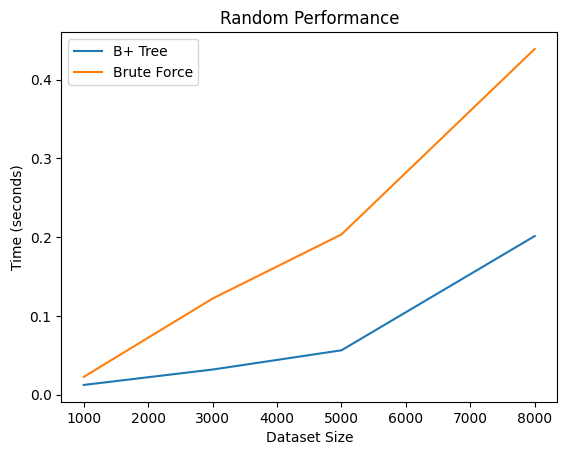

In [20]:
plt.figure()
plt.plot(sizes, bpt_random, label="B+ Tree")
plt.plot(sizes, bf_random, label="Brute Force")
plt.xlabel("Dataset Size")
plt.ylabel("Time (seconds)")
plt.title("Random Performance")
plt.legend()
plt.show()

Random performance evaluates the behavior of both data structures under a mixed workload of insertions, searches, and deletions.

In the brute-force implementation:

- All operations (insert, search, delete) are performed using hashing
- Each operation executes in constant time on average

This results in an overall time complexity of:

\[
O(1)
\]

for each individual operation.

In contrast, the B+ Tree handles each operation through structured traversal:

- Insert, search, and delete operations all require tree traversal \(O(\log n)\)
- Additional overhead is introduced due to node splitting and merging

This results in:

\[
O(log n)
\]

for each operation.

##### Observation

In mixed workloads, the brute-force approach generally performs faster due to constant-time operations.

However, the B+ Tree provides better organization of data and maintains sorted order throughout all operations. This makes it more suitable for applications where ordered access and range queries are required.

As the dataset size increases, the performance difference becomes more noticeable, but the B+ Tree offers greater flexibility and scalability.

### Memory Usage

In [21]:
import sys

sizes = [1000, 3000, 5000, 8000]

bpt_memory = []
bf_memory = []

def get_size(obj):
    return sys.getsizeof(obj)

for size in sizes:
    print(f"Memory test for size: {size}")

    keys = random.sample(range(1, 100000), size)

    bpt = BPlusTree(order=8)
    bf = BruteForceDB()

    for k in keys:
        bpt.insert(k, k)
        bf.insert(k, k)

    bpt_memory.append(get_size(bpt))
    bf_memory.append(get_size(bf.data))

Memory test for size: 1000
Memory test for size: 3000
Memory test for size: 5000
Memory test for size: 8000


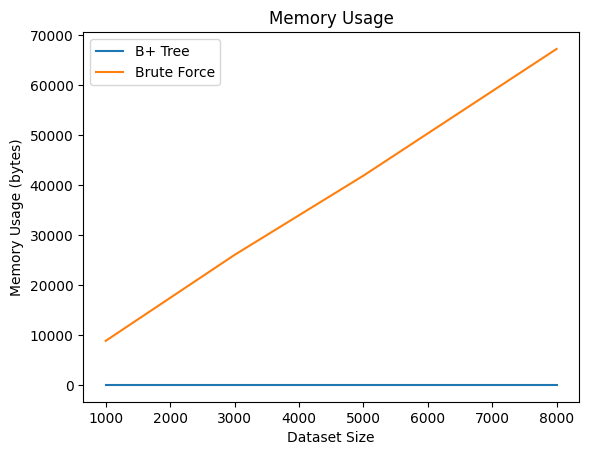

In [22]:
plt.figure()
plt.plot(sizes, bpt_memory, label="B+ Tree")
plt.plot(sizes, bf_memory, label="Brute Force")
plt.xlabel("Dataset Size")
plt.ylabel("Memory Usage (bytes)")
plt.title("Memory Usage")
plt.legend()
plt.show()

Memory usage analysis compares the space efficiency of both data structures.

In the brute-force implementation:

- Data is stored in a single dictionary structure
- Only key-value pairs are maintained without additional structural overhead

This results in relatively low memory usage.

In contrast, the B+ Tree requires additional memory for maintaining its structure:

- Multiple nodes are created to organize data hierarchically
- Each node stores keys, values, and child pointers
- Leaf nodes also maintain next pointers for sequential access

This results in higher memory consumption compared to the brute-force approach.

##### Observation

The B+ Tree consumes more memory due to its hierarchical organization and additional pointers.

However, this overhead enables efficient operations such as range queries and ordered traversal. The extra memory usage is a trade-off for improved performance in structured operations.

This demonstrates that while brute-force is more space-efficient, the B+ Tree is optimized for performance in complex data access scenarios.

### Automated Benchmarking

In [23]:
def run_benchmark(size):
    keys = random.sample(range(1, size * 10), size)

    bpt = BPlusTree(order=8)
    bf = BruteForceDB()

    # INSERT
    start = time.time()
    for k in keys:
        bpt.insert(k, k)
    bpt_insert = time.time() - start

    start = time.time()
    for k in keys:
        bf.insert(k, k)
    bf_insert = time.time() - start

    # SEARCH
    search_keys = random.sample(keys, min(500, size))

    start = time.time()
    for k in search_keys:
        bpt.search(k)
    bpt_search = time.time() - start

    start = time.time()
    for k in search_keys:
        bf.search(k)
    bf_search = time.time() - start

    # RANGE QUERY
    start_key = size // 10
    end_key = size // 2

    start = time.time()
    bpt.range_query(start_key, end_key)
    bpt_range = time.time() - start

    start = time.time()
    bf.range_query(start_key, end_key)
    bf_range = time.time() - start

    # DELETE
    delete_keys = random.sample(keys, min(500, size))

    start = time.time()
    for k in delete_keys:
        bpt.delete(k)
    bpt_delete = time.time() - start

    start = time.time()
    for k in delete_keys:
        bf.delete(k)
    bf_delete = time.time() - start

    return {
        "size": size,
        "bpt_insert": bpt_insert,
        "bf_insert": bf_insert,
        "bpt_search": bpt_search,
        "bf_search": bf_search,
        "bpt_range": bpt_range,
        "bf_range": bf_range,
        "bpt_delete": bpt_delete,
        "bf_delete": bf_delete
    }


sizes = [1000, 3000, 5000, 8000]
results = []

for s in sizes:
    results.append(run_benchmark(s))

for r in results:
    print(f"\nSize: {r['size']}")
    print(f"Insert  -> B+ Tree: {r['bpt_insert']:.6f}, BruteForce: {r['bf_insert']:.6f}")
    print(f"Search  -> B+ Tree: {r['bpt_search']:.6f}, BruteForce: {r['bf_search']:.6f}")
    print(f"Range   -> B+ Tree: {r['bpt_range']:.6f}, BruteForce: {r['bf_range']:.6f}")
    print(f"Delete  -> B+ Tree: {r['bpt_delete']:.6f}, BruteForce: {r['bf_delete']:.6f}")


Size: 1000
Insert  -> B+ Tree: 0.005497, BruteForce: 0.000000
Search  -> B+ Tree: 0.000000, BruteForce: 0.016022
Range   -> B+ Tree: 0.000000, BruteForce: 0.000000
Delete  -> B+ Tree: 0.005277, BruteForce: 0.019685

Size: 3000
Insert  -> B+ Tree: 0.025466, BruteForce: 0.000000
Search  -> B+ Tree: 0.001964, BruteForce: 0.057235
Range   -> B+ Tree: 0.000000, BruteForce: 0.002085
Delete  -> B+ Tree: 0.010557, BruteForce: 0.094771

Size: 5000
Insert  -> B+ Tree: 0.037720, BruteForce: 0.001017
Search  -> B+ Tree: 0.005018, BruteForce: 0.083077
Range   -> B+ Tree: 0.000000, BruteForce: 0.000000
Delete  -> B+ Tree: 0.003902, BruteForce: 0.168227

Size: 8000
Insert  -> B+ Tree: 0.065304, BruteForce: 0.002334
Search  -> B+ Tree: 0.002229, BruteForce: 0.178900
Range   -> B+ Tree: 0.000865, BruteForce: 0.000675
Delete  -> B+ Tree: 0.007654, BruteForce: 0.357276


Automated benchmarking ensures consistent and systematic evaluation of performance across different dataset sizes.

In this approach:

- A benchmarking function is used to execute operations such as insertion and search
- The function is run for multiple dataset sizes
- Execution times are recorded and compared

This allows performance trends to be observed as the dataset grows.

##### Observation

Automated benchmarking eliminates manual inconsistencies and ensures repeatable results.

The results confirm that:

- BruteForceDB performs faster for simple operations due to constant-time complexity
- B+ Tree exhibits predictable logarithmic growth
- Performance differences become more apparent as dataset size increases

This approach provides a reliable way to validate theoretical time complexities using empirical data.

# Visualization

Graphviz was used to visualize the B+ Tree structure.

The visualization shows:
- The hierarchical arrangement of nodes
- Distribution of keys across different levels
- Parent-child relationships

This visualization helps in understanding how the tree grows dynamically and maintains balance through node splitting and merging.

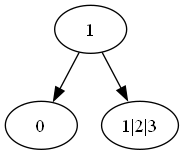

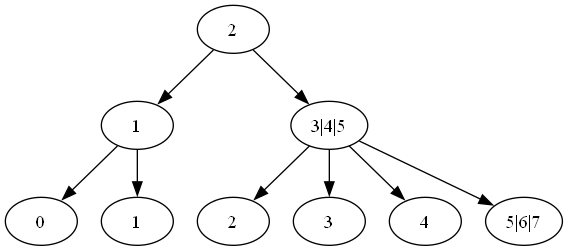

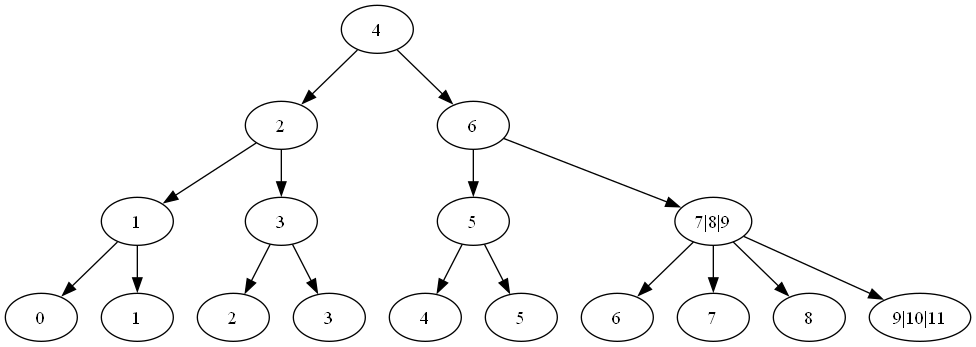

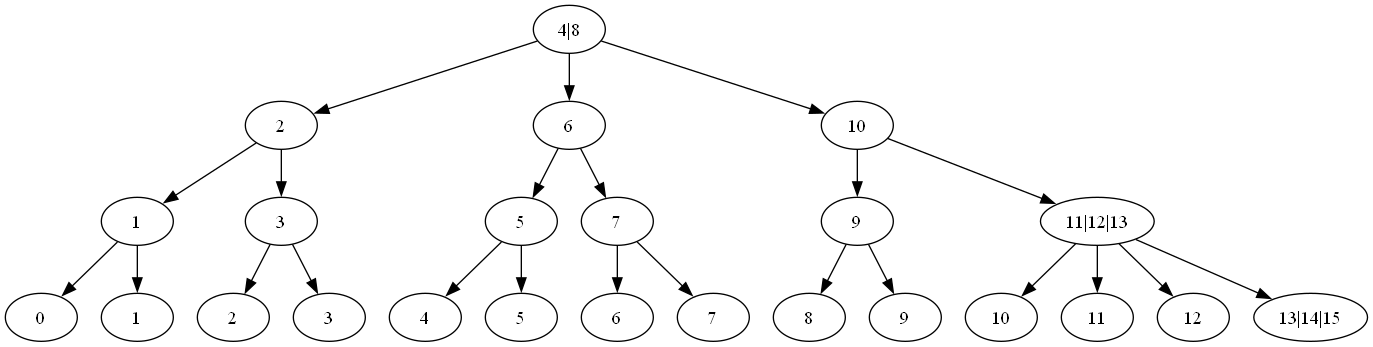

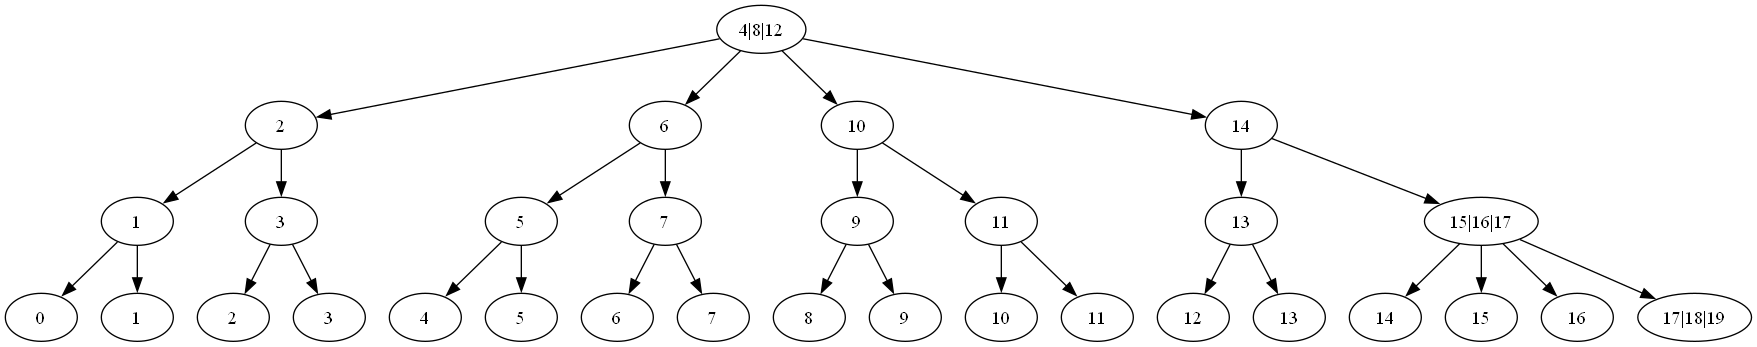

In [24]:
from IPython.display import Image, display

bpt = BPlusTree(order=4)

for i in range(20):
    bpt.insert(i, i)

    if i in [3, 7, 11, 15, 19]:
        filename = f"bptree_step_{i}"
        bpt.visualize_tree(filename)
        display(Image(filename + ".png"))

In [25]:
print("Range Query (5 to 15):")
print(bpt.range_query(5, 15))

Range Query (5 to 15):
[(5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 11), (12, 12), (13, 13), (14, 14), (15, 15)]


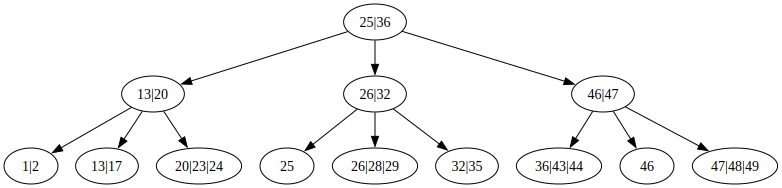

In [26]:
bpt = BPlusTree(order=4)
keys = random.sample(range(1, 50), 20)

for k in keys:
    bpt.insert(k, k)

bpt.visualize_tree("bptree_random")

## Tree Structure Analysis

The visualization shows how the B+ Tree maintains balance:
- Keys are distributed across multiple levels
- Internal nodes act as routing indexes
- Leaf nodes contain actual data and are linked sequentially

This structure ensures efficient traversal and supports fast range queries.

## Time Complexity Comparison

| Operation     | B+ Tree              | Brute Force (Dictionary) |
|--------------|---------------------|--------------------------|
| Insert       | O(log n)            | O(1)                     |
| Search       | O(log n)            | O(1)                     |
| Delete       | O(log n) +          | O(1)                     |
| Range Query  | O(log n + k)        | O(n)                     |

# Conclusion

This project demonstrates the implementation of a lightweight database system using a B+ Tree as the indexing structure.

The B+ Tree provides a balanced and efficient way to manage large datasets, supporting logarithmic time complexity for most operations. 
Its ability to handle range queries efficiently makes it particularly suitable for database applications.

In comparison, the brute-force approach using a dictionary offers fast exact lookups but lacks efficiency for range-based operations.

The implementation successfully integrates:
- B+ Tree indexing
- Table abstraction
- Database management system

### Challenges Faced

- Implementing correct node splitting logic without losing data
- Handling edge cases during deletion (underflow, merging, borrowing)
- Maintaining correct parent-child relationships
- Ensuring leaf node linkage for range queries

These challenges required careful debugging and testing of multiple edge cases.

### Future Improvements

- Implement disk-based storage for large datasets
- Add support for composite keys
- Improve visualization to include leaf node links
- Optimize deletion logic further

These improvements would make the system closer to real-world database engines.

Overall, the project highlights the importance of structured indexing in improving database performance.